# GitHub AI-Agent Star Velocity

This notebook asks how much developer attention is visible in a sampled set of GitHub stargazer timestamps. Star velocity is useful for launch and attention analysis, but it is sensitive to repository choice, token limits, pagination depth, bots, and the covered window.

The main output is a repo basket, a source card, a coverage table, and a residual-event view over the fetched stargazer window.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Select repositories

Use a small basket for unauthenticated runs. Set `GITHUB_TOKEN` for higher rate limits and record the repository list because basket selection changes the result.


In [2]:
repos = [
    "langchain-ai/langchain",
    "microsoft/autogen",
    "crewAIInc/crewAI",
    "browser-use/browser-use",
    "modelcontextprotocol/servers",
]
token = os.environ.get("GITHUB_TOKEN")
pd.DataFrame({"repo": repos})


,repo
0,langchain-ai/langchain
1,microsoft/autogen
2,crewAIInc/crewAI
3,browser-use/browser-use
4,modelcontextprotocol/servers


## 2. Fetch repository metadata


In [3]:
metadata_rows = []
for repo in repos:
    meta = fetch_github_repo_metadata(repo, token=token)
    metadata_rows.append({
        "repo": repo,
        "stars": meta.get("stargazers_count"),
        "forks": meta.get("forks_count"),
        "open_issues": meta.get("open_issues_count"),
        "pushed_at": meta.get("pushed_at"),
        "source": "GitHub REST API",
        "endpoint": f"https://api.github.com/repos/{repo}",
    })
metadata = pd.DataFrame(metadata_rows).sort_values("stars", ascending=False)
metadata


,repo,stars,forks,open_issues,pushed_at,source,endpoint
0,langchain-ai/langchain,137416,22731,581,2026-05-22T21:27:05Z,GitHub REST API,https://api.github.com/repos/langchain-ai/lang...
3,browser-use/browser-use,95129,10715,227,2026-05-22T20:58:44Z,GitHub REST API,https://api.github.com/repos/browser-use/brows...
4,modelcontextprotocol/servers,86094,10787,510,2026-05-21T18:10:38Z,GitHub REST API,https://api.github.com/repos/modelcontextproto...
1,microsoft/autogen,58298,8804,846,2026-04-15T11:59:09Z,GitHub REST API,https://api.github.com/repos/microsoft/autogen
2,crewAIInc/crewAI,51979,7204,353,2026-05-22T19:50:26Z,GitHub REST API,https://api.github.com/repos/crewAIInc/crewAI


## 3. Fetch sampled stargazer timestamps

This notebook fetches a bounded number of stargazer pages for each repository. The result is a sampled history window, not complete production adoption. Increase pages or run a scheduled collection for deeper coverage.


In [4]:
STARGAZER_PAGES = 3
PER_PAGE = 100
source_card = pd.DataFrame([{
    "source": "GitHub REST API",
    "endpoint": "https://api.github.com/repos/{repo}/stargazers",
    "access_date": pd.Timestamp.today().date().isoformat(),
    "query_params": f"repos={len(repos)}; pages={STARGAZER_PAGES}; per_page={PER_PAGE}; token_used={bool(token)}",
    "time_range": "derived from fetched starred_at timestamps below",
    "cache_path": "not cached; outputs saved to examples/hot_trends/outputs",
    "interpretation_scope": "star velocity measures developer attention in the fetched window; stars are not production usage",
}])
star_rows = []
for repo in repos:
    sg = fetch_github_stargazers(repo, pages=STARGAZER_PAGES, per_page=PER_PAGE, token=token)
    star_rows.append(sg)
stars = pd.concat(star_rows, ignore_index=True)
display(source_card)
stars.head(20)


,source,endpoint,access_date,query_params,time_range,cache_path,interpretation_scope
0,GitHub REST API,https://api.github.com/repos/{repo}/stargazers,2026-05-22,repos=5; pages=3; per_page=100; token_used=False,derived from fetched starred_at timestamps below,not cached; outputs saved to examples/hot_tren...,star velocity measures developer attention in ...


,repo,starred_at,login,source,data_quality
0,langchain-ai/langchain,2022-10-25T15:45:15Z,JohnShahawy,GitHub REST API,public_api_snapshot
1,langchain-ai/langchain,2022-10-25T16:47:34Z,davidtsong,GitHub REST API,public_api_snapshot
2,langchain-ai/langchain,2022-10-25T16:50:28Z,salomartin,GitHub REST API,public_api_snapshot
3,langchain-ai/langchain,2022-10-25T16:57:12Z,sjwhitmore,GitHub REST API,public_api_snapshot
4,langchain-ai/langchain,2022-10-25T17:00:55Z,achuthasubhash,GitHub REST API,public_api_snapshot
5,langchain-ai/langchain,2022-10-25T17:06:38Z,Agrover112,GitHub REST API,public_api_snapshot
6,langchain-ai/langchain,2022-10-25T17:14:31Z,gemasphi,GitHub REST API,public_api_snapshot
7,langchain-ai/langchain,2022-10-25T17:15:00Z,robinsingh1,GitHub REST API,public_api_snapshot
8,langchain-ai/langchain,2022-10-25T17:17:23Z,jvmncs,GitHub REST API,public_api_snapshot
9,langchain-ai/langchain,2022-10-25T17:25:58Z,vvonchain,GitHub REST API,public_api_snapshot


## 4. Convert stargazer timestamps to daily velocity


In [5]:
stars["date"] = pd.to_datetime(stars["starred_at"]).dt.normalize()
raw_daily = stars.groupby(["repo", "date"]).size().reset_index(name="count")
calendar_rows = []
for repo, sub in raw_daily.groupby("repo"):
    calendar = pd.date_range(sub["date"].min(), sub["date"].max(), freq="D")
    filled = sub.set_index("date").reindex(calendar, fill_value=0).rename_axis("date").reset_index()
    filled["repo"] = repo
    calendar_rows.append(filled[["repo", "date", "count"]])
daily = pd.concat(calendar_rows, ignore_index=True)
daily["date"] = daily["date"].dt.date.astype(str)
raw_daily["date"] = raw_daily["date"].dt.date.astype(str)
daily.head(20)


,repo,date,count
0,browser-use/browser-use,2024-11-05,166
1,browser-use/browser-use,2024-11-06,134
2,crewAIInc/crewAI,2023-11-14,8
3,crewAIInc/crewAI,2023-11-15,4
4,crewAIInc/crewAI,2023-11-16,0
5,crewAIInc/crewAI,2023-11-17,0
6,crewAIInc/crewAI,2023-11-18,0
7,crewAIInc/crewAI,2023-11-19,0
8,crewAIInc/crewAI,2023-11-20,0
9,crewAIInc/crewAI,2023-11-21,0


## Visualization: GitHub star velocity

The x-axis is the fetched stargazer window and the y-axis is stars per day after missing calendar days are filled with zero. Treat the line as attention in the sampled window; do not compare repositories without checking coverage.


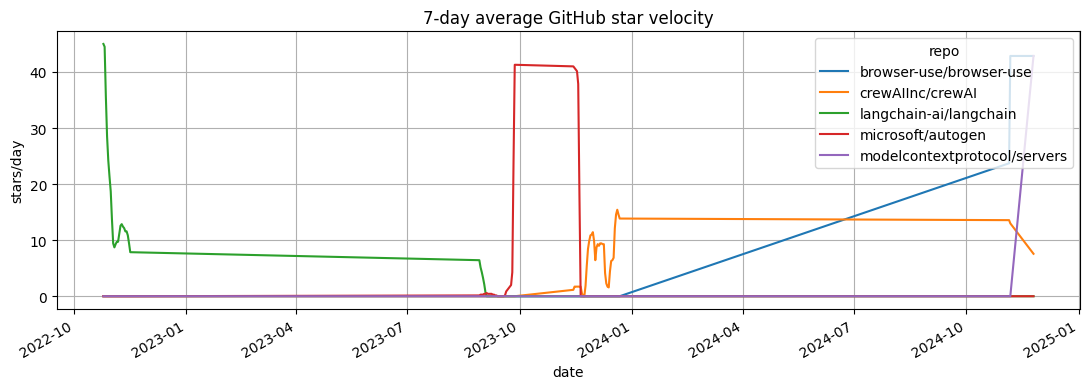

In [6]:
star_velocity = daily.copy()
star_velocity["date"] = pd.to_datetime(star_velocity["date"])
velocity_pivot = star_velocity.pivot_table(index="date", columns="repo", values="count", aggfunc="sum").fillna(0).sort_index()
ax = velocity_pivot.rolling(7, min_periods=1).mean().plot(figsize=(11, 4), title="7-day average GitHub star velocity")
ax.set_ylabel("stars/day")
ax.set_xlabel("date")
plt.tight_layout()
plt.show()


## 5. Decompose star velocity if enough days exist


In [7]:
coverage = source_audit_table(raw_daily, value_col="count", entity_col="repo", time_col="date")
calendar_coverage = daily.groupby("repo").agg(calendar_days=("date", "nunique"), total_fetched_stars=("count", "sum")).reset_index().rename(columns={"repo": "series"})
coverage = coverage.merge(calendar_coverage, on="series", how="left")
coverage["pages_per_repo"] = STARGAZER_PAGES
coverage["per_page"] = PER_PAGE
ready = coverage.loc[coverage["calendar_days"] >= 14, "series"].tolist()
if ready:
    components = decompose_table(daily[daily["repo"].isin(ready)], entity_col="repo", time_col="date", value_col="count", method="MA_BASELINE", period=7, trend_window=5, transform="log1p")
    summary = editorial_priority(component_summary(components, entity_col="repo", time_col="date"), entity_col="repo")
    events = residual_event_table(components, entity_col="repo", time_col="date", top_n=20, trim_edges=7)
else:
    components = pd.DataFrame()
    summary = pd.DataFrame([{"status": "not_enough_stargazer_calendar_days", "required": "increase pages or run repeated snapshots"}])
    events = pd.DataFrame()
coverage


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value,calendar_days,total_fetched_stars,pages_per_repo,per_page
0,browser-use/browser-use,2024-11-05 00:00:00,2024-11-06 00:00:00,2,0.0,134.0,166.0,2,300,3,100
1,crewAIInc/crewAI,2023-11-14 00:00:00,2023-12-22 00:00:00,31,0.0,1.0,38.0,39,300,3,100
2,langchain-ai/langchain,2022-10-25 00:00:00,2022-11-16 00:00:00,23,0.0,3.0,45.0,23,300,3,100
3,microsoft/autogen,2023-08-29 00:00:00,2023-09-27 00:00:00,14,0.0,1.0,138.0,30,300,3,100
4,modelcontextprotocol/servers,2024-11-25 00:00:00,2024-11-25 00:00:00,1,0.0,300.0,300.0,1,300,3,100


## Visualization: GitHub coverage and residual events

Coverage bars show fetched stargazer days by repository. The residual panel highlights unusually large deviations after calendar zero-fill and edge trimming; inspect the event date before treating it as launch evidence.


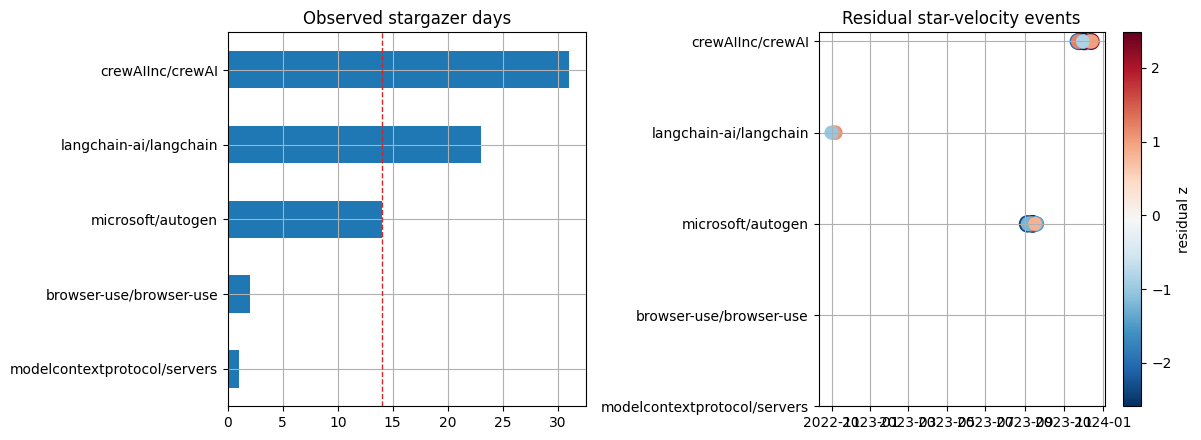

In [8]:
coverage_plot = coverage.sort_values("observations")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
coverage_plot.plot(kind="barh", x="series", y="observations", ax=axes[0], color="tab:blue", legend=False, title="Observed stargazer days")
axes[0].axvline(14, color="tab:red", linestyle="--", linewidth=1.0)
axes[0].set_ylabel("")
if events.empty:
    axes[1].axis("off")
    axes[1].set_title("No residual events until coverage threshold is met")
else:
    event_plot = events.copy()
    event_plot["date"] = pd.to_datetime(event_plot["date"])
    repo_order = coverage_plot["series"].tolist()
    event_plot["repo_code"] = pd.Categorical(event_plot["repo"], categories=repo_order, ordered=True).codes
    sc = axes[1].scatter(event_plot["date"], event_plot["repo_code"], s=50 + event_plot["abs_residual_z"] * 35, c=event_plot["residual_z"], cmap="RdBu_r")
    axes[1].set_yticks(range(len(repo_order)))
    axes[1].set_yticklabels(repo_order)
    axes[1].set_title("Residual star-velocity events")
    fig.colorbar(sc, ax=axes[1], label="residual z")
plt.tight_layout()
plt.show()


In [9]:
summary


,repo,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
2,microsoft/autogen,30,2023-08-29 00:00:00,2023-09-27 00:00:00,2.523944,0.070044,0.822280,0.540199,4.627360,MA_BASELINE,1.000000,1.000000,1.000000,1.000000
0,crewAIInc/crewAI,39,2023-11-14 00:00:00,2023-12-22 00:00:00,1.499108,0.043173,0.629650,0.701591,2.245717,MA_BASELINE,0.666667,0.666667,0.333333,0.516667
1,langchain-ai/langchain,23,2022-10-25 00:00:00,2022-11-16 00:00:00,1.277376,-0.021586,0.601288,0.353917,3.217347,MA_BASELINE,0.333333,0.333333,0.666667,0.483333


## 6. Publication language


In [10]:
phrasing = article_publication_phrasing()
phrasing


,draft_claim,evidence_based_phrasing
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy interpre...
2,This repo is winning because stars are rising.,Star velocity measures developer attention for...
3,This pageview spike shows the topic matters most.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [11]:
save_table(source_card, "04_github_source_card")
save_table(metadata, "04_github_repo_metadata")
save_table(coverage, "04_github_stargazer_coverage")
save_table(daily, "04_github_star_velocity_daily")
save_table(summary, "04_github_decomposition_or_collection_status")
if not events.empty:
    save_table(events, "04_github_residual_events")
save_table(phrasing, "04_github_publication_phrasing")


saved: examples/hot_trends/outputs/04_github_source_card.csv
saved: examples/hot_trends/outputs/04_github_repo_metadata.csv
saved: examples/hot_trends/outputs/04_github_stargazer_coverage.csv
saved: examples/hot_trends/outputs/04_github_star_velocity_daily.csv
saved: examples/hot_trends/outputs/04_github_decomposition_or_collection_status.csv
saved: examples/hot_trends/outputs/04_github_residual_events.csv
saved: examples/hot_trends/outputs/04_github_publication_phrasing.csv
